In [2]:
!pip install ultralytics

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.4/46.4 kB 1.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 23.1 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.2/53.2 kB 3.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 69.0/69.0 kB 3.9 MB/s eta 0:00:00


In [8]:
# pip install ultralytics opencv-python pandas matplotlib --quiet

import cv2
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from ultralytics import YOLO
from collections import defaultdict

MODEL_PATH = '/kaggle/input/notebooks/ronak038/ins-claim-cardd/car_damage_best.pt'          # <-- adjust if needed
VIDEOS_DIR = '/kaggle/input/datasets/ronak038/sample-video-with-audio/ground_truth_manifest.json'                   
MANIFEST_PATH = os.path.join(VIDEOS_DIR, '/kaggle/input/datasets/ronak038/sample-video-with-audio/ground_truth_manifest.json')
CLASS_NAMES = ['dent', 'scratch', 'crack', 'glass shatter', 'lamp broken', 'tire flat']

model = YOLO(MODEL_PATH)

with open(MANIFEST_PATH) as f:
    manifest = json.load(f)

print(f'Loaded model and manifest with {len(manifest)} videos.')

Loaded model and manifest with 26 videos.


In [9]:
def extract_frames_scene_change(video_path, diff_threshold=25.0, min_gap_frames=5):
    cap = cv2.VideoCapture(video_path)
    frames = []
    frame_idx = 0
    prev_gray_small = None
    last_captured_idx = -min_gap_frames

    while True:
        ret, frame = cap.read()
        if not ret:
            break
        small = cv2.resize(frame, (160, 90))
        gray_small = cv2.cvtColor(small, cv2.COLOR_BGR2GRAY)

        should_capture = prev_gray_small is None
        if not should_capture:
            diff = np.mean(cv2.absdiff(gray_small, prev_gray_small))
            if diff > diff_threshold and (frame_idx - last_captured_idx) >= min_gap_frames:
                should_capture = True

        if should_capture:
            frames.append(frame)
            prev_gray_small = gray_small
            last_captured_idx = frame_idx
        frame_idx += 1

    cap.release()
    return frames


def predict_damage_types_for_video(video_path, conf_threshold=0.20, min_frame_consistency=0.10):
    """Returns the set of damage classes the model predicts are present in this video,
    requiring a class to appear in at least `min_frame_consistency` fraction of sampled frames
    to count as a real detection (filters out single-frame noise/flicker).
    """
    frames = extract_frames_scene_change(video_path)
    if not frames:
        return set(), 0, {}

    class_frame_counts = defaultdict(int)
    class_max_conf = defaultdict(float)

    for frame in frames:
        result = model.predict(frame, conf=conf_threshold, verbose=False)[0]
        seen_this_frame = set()
        for box in result.boxes:
            cls_id = int(box.cls.item())
            cls_name = CLASS_NAMES[cls_id]
            conf = float(box.conf.item())
            if cls_name not in seen_this_frame:
                class_frame_counts[cls_name] += 1
                seen_this_frame.add(cls_name)
            class_max_conf[cls_name] = max(class_max_conf[cls_name], conf)

    total_frames = len(frames)
    predicted_classes = {
        cls for cls, count in class_frame_counts.items()
        if (count / total_frames) >= min_frame_consistency
    }

    detail = {
        cls: {
            'frame_count': class_frame_counts[cls],
            'total_frames': total_frames,
            'consistency_pct': round(100 * class_frame_counts[cls] / total_frames, 1),
            'max_confidence': round(class_max_conf[cls], 3),
            'passed_threshold': cls in predicted_classes
        }
        for cls in class_frame_counts
    }

    return predicted_classes, total_frames, detail

In [18]:
for video_name, info in manifest.items():
    print(info)

{'source_images': ['003879.jpg', '001671.jpg', '002624.jpg'], 'expected_damage_types': ['dent', 'lamp broken', 'scratch'], 'video_type': 'single_class_focus', 'narration_style': 'distressed', 'narration_text': 'So, um, this is really frustrating, but, uh, my vehicle has dent, lamp broken, and a scratch. I, um, I just want this resolved quickly, uh, if possible.', 'narration_audio_path': 'sample_audio/claim_single_dent_v1.wav', 'audio_duration_sec': 6.41, 'video_duration_sec': 9.0, 'final_video_with_audio_path': 'sample_videos_with_audio/claim_single_dent_v1.mp4'}
{'source_images': ['002062.jpg', '000044.jpg', '000625.jpg'], 'expected_damage_types': ['crack', 'dent', 'scratch'], 'video_type': 'single_class_focus', 'narration_style': 'distressed', 'narration_text': 'So, um, this is really frustrating, but, uh, my vehicle has crack, dent, and a scratch. I, um, I just want this resolved quickly, uh, if possible.', 'narration_audio_path': 'sample_audio/claim_single_dent_v2.wav', 'audio_dura

In [19]:
print(VIDEOS_DIR)

/kaggle/input/datasets/ronak038/sample-video-with-audio/ground_truth_manifest.json


In [21]:
evaluation_rows = []
detailed_predictions = {}

for video_name, info in manifest.items():
    video_path = os.path.join('/kaggle/input/datasets/ronak038/sample-video-with-audio', video_name)
    print(video_path)
    if not os.path.exists(video_path):
        print(f'WARNING: {video_path} not found, skipping.')
        continue

    print(f'Evaluating: {video_name}...')
    predicted_classes, n_frames, detail = predict_damage_types_for_video(video_path)
    expected_classes = set(info['expected_damage_types'])

    detailed_predictions[video_name] = detail

    evaluation_rows.append({
        'video_name': video_name,
        'video_type': info.get('video_type', 'unknown'),
        'expected': sorted(expected_classes),
        'predicted': sorted(predicted_classes),
        'correct_matches': sorted(expected_classes & predicted_classes),
        'missed_(false_negatives)': sorted(expected_classes - predicted_classes),
        'extra_(false_positives)': sorted(predicted_classes - expected_classes),
        'exact_match': expected_classes == predicted_classes,
        'frames_analyzed': n_frames
    })

eval_df = pd.DataFrame(evaluation_rows)
eval_df

/kaggle/input/datasets/ronak038/sample-video-with-audio/claim_single_dent_v1.mp4
Evaluating: claim_single_dent_v1.mp4...
/kaggle/input/datasets/ronak038/sample-video-with-audio/claim_single_dent_v2.mp4
Evaluating: claim_single_dent_v2.mp4...
/kaggle/input/datasets/ronak038/sample-video-with-audio/claim_single_scratch_v1.mp4
Evaluating: claim_single_scratch_v1.mp4...
/kaggle/input/datasets/ronak038/sample-video-with-audio/claim_single_scratch_v2.mp4
Evaluating: claim_single_scratch_v2.mp4...
/kaggle/input/datasets/ronak038/sample-video-with-audio/claim_single_crack_v1.mp4
Evaluating: claim_single_crack_v1.mp4...
/kaggle/input/datasets/ronak038/sample-video-with-audio/claim_single_crack_v2.mp4
Evaluating: claim_single_crack_v2.mp4...
/kaggle/input/datasets/ronak038/sample-video-with-audio/claim_single_glass_shatter_v1.mp4
Evaluating: claim_single_glass_shatter_v1.mp4...
/kaggle/input/datasets/ronak038/sample-video-with-audio/claim_single_glass_shatter_v2.mp4
Evaluating: claim_single_glas

,video_name,video_type,expected,predicted,correct_matches,missed_(false_negatives),extra_(false_positives),exact_match,frames_analyzed
0,claim_single_dent_v1.mp4,single_class_focus,"[dent, lamp broken, scratch]","[crack, dent, lamp broken, scratch]","[dent, lamp broken, scratch]",[],[crack],False,14
1,claim_single_dent_v2.mp4,single_class_focus,"[crack, dent, scratch]","[crack, dent, scratch]","[crack, dent, scratch]",[],[],True,12
2,claim_single_scratch_v1.mp4,single_class_focus,"[crack, dent, lamp broken, scratch]","[crack, dent, lamp broken, scratch]","[crack, dent, lamp broken, scratch]",[],[],True,7
3,claim_single_scratch_v2.mp4,single_class_focus,"[dent, lamp broken, scratch]","[dent, lamp broken, scratch]","[dent, lamp broken, scratch]",[],[],True,9
4,claim_single_crack_v1.mp4,single_class_focus,"[crack, dent, lamp broken, scratch]","[crack, dent, lamp broken, scratch]","[crack, dent, lamp broken, scratch]",[],[],True,10
5,claim_single_crack_v2.mp4,single_class_focus,"[crack, dent, lamp broken, scratch]","[crack, dent, lamp broken, scratch]","[crack, dent, lamp broken, scratch]",[],[],True,9
6,claim_single_glass_shatter_v1.mp4,single_class_focus,[glass shatter],[glass shatter],[glass shatter],[],[],True,20
7,claim_single_glass_shatter_v2.mp4,single_class_focus,[glass shatter],[glass shatter],[glass shatter],[],[],True,12
8,claim_single_lamp_broken_v1.mp4,single_class_focus,"[crack, lamp broken]","[crack, lamp broken]","[crack, lamp broken]",[],[],True,11
9,claim_single_lamp_broken_v2.mp4,single_class_focus,"[dent, lamp broken, scratch]","[dent, lamp broken, scratch]","[dent, lamp broken, scratch]",[],[],True,26


In [22]:
for row in evaluation_rows:
    status = '✓ EXACT MATCH' if row['exact_match'] else '✗ MISMATCH'
    print(f"\n{row['video_name']} [{status}]")
    print(f"  Expected:  {row['expected']}")
    print(f"  Predicted: {row['predicted']}")
    if row['missed_(false_negatives)']:
        print(f"  ⚠ MISSED (model failed to detect): {row['missed_(false_negatives)']}")
    if row['extra_(false_positives)']:
        print(f"  ⚠ FALSE POSITIVE (model over-detected): {row['extra_(false_positives)']}")


claim_single_dent_v1.mp4 [✗ MISMATCH]
  Expected:  ['dent', 'lamp broken', 'scratch']
  Predicted: ['crack', 'dent', 'lamp broken', 'scratch']
  ⚠ FALSE POSITIVE (model over-detected): ['crack']

claim_single_dent_v2.mp4 [✓ EXACT MATCH]
  Expected:  ['crack', 'dent', 'scratch']
  Predicted: ['crack', 'dent', 'scratch']

claim_single_scratch_v1.mp4 [✓ EXACT MATCH]
  Expected:  ['crack', 'dent', 'lamp broken', 'scratch']
  Predicted: ['crack', 'dent', 'lamp broken', 'scratch']

claim_single_scratch_v2.mp4 [✓ EXACT MATCH]
  Expected:  ['dent', 'lamp broken', 'scratch']
  Predicted: ['dent', 'lamp broken', 'scratch']

claim_single_crack_v1.mp4 [✓ EXACT MATCH]
  Expected:  ['crack', 'dent', 'lamp broken', 'scratch']
  Predicted: ['crack', 'dent', 'lamp broken', 'scratch']

claim_single_crack_v2.mp4 [✓ EXACT MATCH]
  Expected:  ['crack', 'dent', 'lamp broken', 'scratch']
  Predicted: ['crack', 'dent', 'lamp broken', 'scratch']

claim_single_glass_shatter_v1.mp4 [✓ EXACT MATCH]
  Expected:  

In [24]:
total_tp = sum(len(row['correct_matches']) for row in evaluation_rows)
total_fn = sum(len(row['missed_(false_negatives)']) for row in evaluation_rows)
total_fp = sum(len(row['extra_(false_positives)']) for row in evaluation_rows)

precision = total_tp / (total_tp + total_fp) if (total_tp + total_fp) > 0 else 0
recall = total_tp / (total_tp + total_fn) if (total_tp + total_fn) > 0 else 0
f1 = 2 * precision * recall / (precision + recall) if (precision + recall) > 0 else 0

exact_match_rate = eval_df['exact_match'].mean()

print('=== OVERALL VIDEO-LEVEL DETECTION METRICS ===\n')
print(f'True Positives (correctly detected damage types):  {total_tp}')
print(f'False Negatives (missed damage types):              {total_fn}')
print(f'False Positives (incorrectly detected damage types): {total_fp}')
print(f'\nPrecision: {precision:.2%}   (of what the model flagged, how much was real)')
print(f'Recall:    {recall:.2%}   (of real damage, how much the model caught)')
print(f'F1 Score:  {f1:.2%}')
print(f'\nExact video match rate: {exact_match_rate:.2%}  ({int(exact_match_rate * len(eval_df))}/{len(eval_df)} videos perfectly matched)')

=== OVERALL VIDEO-LEVEL DETECTION METRICS ===

True Positives (correctly detected damage types):  78
False Negatives (missed damage types):              4
False Positives (incorrectly detected damage types): 6

Precision: 92.86%   (of what the model flagged, how much was real)
Recall:    95.12%   (of real damage, how much the model caught)
F1 Score:  93.98%

Exact video match rate: 69.23%  (18/26 videos perfectly matched)


In [25]:
class_stats = {cls: {'tp': 0, 'fn': 0, 'fp': 0} for cls in CLASS_NAMES}

for row in evaluation_rows:
    for cls in row['correct_matches']:
        class_stats[cls]['tp'] += 1
    for cls in row['missed_(false_negatives)']:
        class_stats[cls]['fn'] += 1
    for cls in row['extra_(false_positives)']:
        class_stats[cls]['fp'] += 1

class_metrics = []
for cls, stats in class_stats.items():
    tp, fn, fp = stats['tp'], stats['fn'], stats['fp']
    total_instances = tp + fn
    if total_instances == 0 and fp == 0:
        continue  # class never appeared in this test set at all, skip
    cls_precision = tp / (tp + fp) if (tp + fp) > 0 else (1.0 if fp == 0 and tp == 0 else 0.0)
    cls_recall = tp / (tp + fn) if (tp + fn) > 0 else None
    class_metrics.append({
        'damage_type': cls,
        'appeared_in_n_videos': total_instances,
        'correctly_detected': tp,
        'missed': fn,
        'false_positives': fp,
        'recall': f'{cls_recall:.0%}' if cls_recall is not None else 'N/A (never present)',
    })

pd.DataFrame(class_metrics)

,damage_type,appeared_in_n_videos,correctly_detected,missed,false_positives,recall
0,dent,20,20,0,0,100%
1,scratch,21,21,0,1,100%
2,crack,14,13,1,3,93%
3,glass shatter,6,5,1,0,83%
4,lamp broken,16,16,0,2,100%
5,tire flat,5,3,2,0,60%


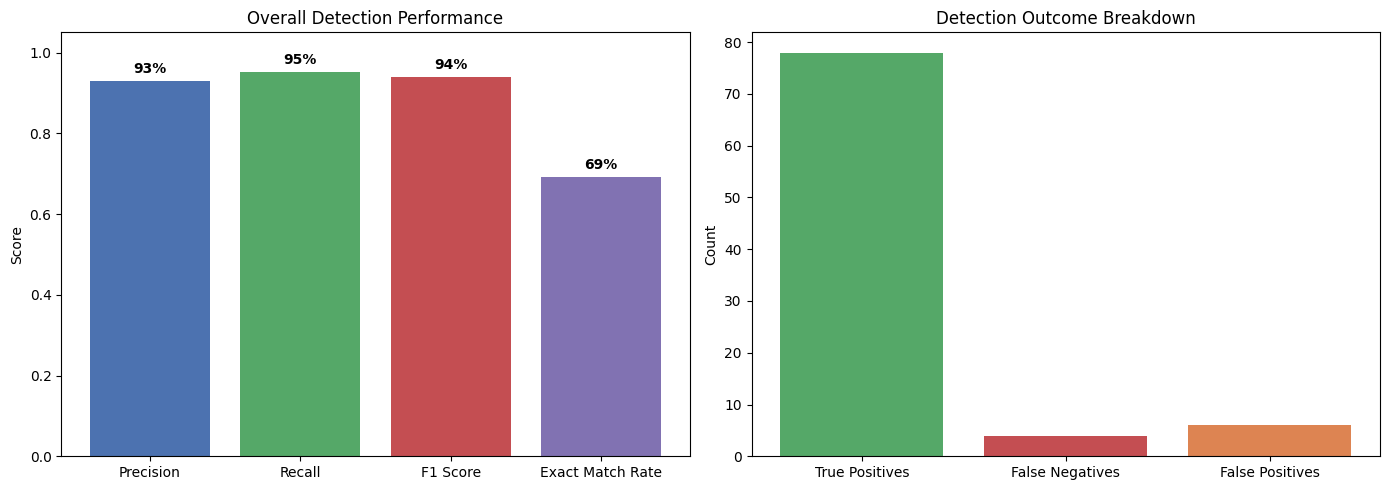

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

metrics_names = ['Precision', 'Recall', 'F1 Score', 'Exact Match Rate']
metrics_values = [precision, recall, f1, exact_match_rate]
bars = axes[0].bar(metrics_names, metrics_values, color=['#4C72B0', '#55A868', '#C44E52', '#8172B2'])
axes[0].set_ylim(0, 1.05)
axes[0].set_ylabel('Score')
axes[0].set_title('Overall Detection Performance')
for bar, val in zip(bars, metrics_values):
    axes[0].text(bar.get_x() + bar.get_width()/2, val + 0.02, f'{val:.0%}', ha='center', fontweight='bold')

axes[1].bar(['True Positives', 'False Negatives', 'False Positives'],
            [total_tp, total_fn, total_fp],
            color=['#55A868', '#C44E52', '#DD8452'])
axes[1].set_ylabel('Count')
axes[1].set_title('Detection Outcome Breakdown')

plt.tight_layout()
plt.show()

In [27]:
mismatched_videos = eval_df[~eval_df['exact_match']]['video_name'].tolist()

if not mismatched_videos:
    print('All videos matched exactly — no mismatches to investigate.')
else:
    for video_name in mismatched_videos:
        print(f'\n--- {video_name} ---')
        for cls, d in detailed_predictions[video_name].items():
            flag = '✓ passed' if d['passed_threshold'] else '✗ filtered out (below consistency threshold)'
            print(f"  {cls}: seen in {d['frame_count']}/{d['total_frames']} frames "
                  f"({d['consistency_pct']}%), max_conf={d['max_confidence']} → {flag}")


--- claim_single_dent_v1.mp4 ---
  dent: seen in 14/14 frames (100.0%), max_conf=0.929 → ✓ passed
  lamp broken: seen in 4/14 frames (28.6%), max_conf=0.948 → ✓ passed
  crack: seen in 2/14 frames (14.3%), max_conf=0.273 → ✓ passed
  scratch: seen in 8/14 frames (57.1%), max_conf=0.896 → ✓ passed

--- claim_single_tire_flat_v1.mp4 ---
  tire flat: seen in 10/18 frames (55.6%), max_conf=0.967 → ✓ passed
  scratch: seen in 8/18 frames (44.4%), max_conf=0.771 → ✓ passed
  dent: seen in 12/18 frames (66.7%), max_conf=0.933 → ✓ passed
  lamp broken: seen in 6/18 frames (33.3%), max_conf=0.401 → ✓ passed

--- claim_pair_dent_scratch.mp4 ---
  crack: seen in 2/9 frames (22.2%), max_conf=0.659 → ✓ passed
  scratch: seen in 9/9 frames (100.0%), max_conf=0.809 → ✓ passed
  dent: seen in 9/9 frames (100.0%), max_conf=0.873 → ✓ passed
  lamp broken: seen in 3/9 frames (33.3%), max_conf=0.944 → ✓ passed

--- claim_pair_dent_tire_flat.mp4 ---
  tire flat: seen in 14/17 frames (82.4%), max_conf=0.97

In [28]:
os.makedirs('reports', exist_ok=True)

final_report = {
    'overall_metrics': {
        'precision': round(precision, 3),
        'recall': round(recall, 3),
        'f1_score': round(f1, 3),
        'exact_match_rate': round(exact_match_rate, 3),
        'total_true_positives': total_tp,
        'total_false_negatives': total_fn,
        'total_false_positives': total_fp
    },
    'per_class_metrics': class_metrics,
    'per_video_results': evaluation_rows,
    'detailed_frame_level_predictions': detailed_predictions
}

with open('reports/detection_evaluation_report.json', 'w') as f:
    json.dump(final_report, f, indent=2)

print('Saved to reports/detection_evaluation_report.json')
print('\nThis is your key accuracy evidence for the demo — use the Section 5/6/7 numbers and charts directly.')

Saved to reports/detection_evaluation_report.json

This is your key accuracy evidence for the demo — use the Section 5/6/7 numbers and charts directly.
